In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

In [2]:
dataset = pd.read_csv("/content/bankmarket.csv", sep=';')


In [3]:
selected_cols = ['age', 'duration', 'campaign', 'previous', 'housing', 'loan']
X = dataset[selected_cols].copy()
y = dataset['y'].copy()

In [4]:
encoder = LabelEncoder()

In [5]:
for column in ['housing', 'loan']:
    X[column] = encoder.fit_transform(X[column])

y = encoder.fit_transform(y)


In [6]:
X = X.fillna(X.mean())

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

In [8]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

In [9]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE :", np.bincount(y_train_bal))


Before SMOTE: [25583  3248]
After SMOTE : [25583 25583]


In [10]:
scaler = StandardScaler()

X_train_bal = scaler.fit_transform(X_train_bal)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


In [11]:
rf_model = RandomForestClassifier(n_estimators=150, random_state=42)
ada_model = AdaBoostClassifier(n_estimators=150, random_state=42)

rf_model.fit(X_train_bal, y_train_bal)
ada_model.fit(X_train_bal, y_train_bal)


AdaBoostClassifier(n_estimators=150, random_state=42)

In [12]:
rf_val = accuracy_score(y_val, rf_model.predict(X_val))
ada_val = accuracy_score(y_val, ada_model.predict(X_val))

print("\n--- Validation Accuracy ---")
print("Random Forest:", rf_val)
print("AdaBoost     :", ada_val)


--- Validation Accuracy ---
Random Forest: 0.8274522499190676
AdaBoost     : 0.7911945613467142


In [13]:
rf_pred = rf_model.predict(X_test)
ada_pred = ada_model.predict(X_test)

print("\n--- Test Accuracy ---")
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("AdaBoost     :", accuracy_score(y_test, ada_pred))



--- Test Accuracy ---
Random Forest: 0.8282893672115229
AdaBoost     : 0.7828127528726331


In [14]:
print(classification_report(y_test, rf_pred))
print(classification_report(y_test, ada_pred))

              precision    recall  f1-score   support

           0       0.94      0.86      0.90      5483
           1       0.34      0.56      0.42       696

    accuracy                           0.83      6179
   macro avg       0.64      0.71      0.66      6179
weighted avg       0.87      0.83      0.85      6179

              precision    recall  f1-score   support

           0       0.96      0.79      0.87      5483
           1       0.30      0.71      0.42       696

    accuracy                           0.78      6179
   macro avg       0.63      0.75      0.64      6179
weighted avg       0.88      0.78      0.82      6179



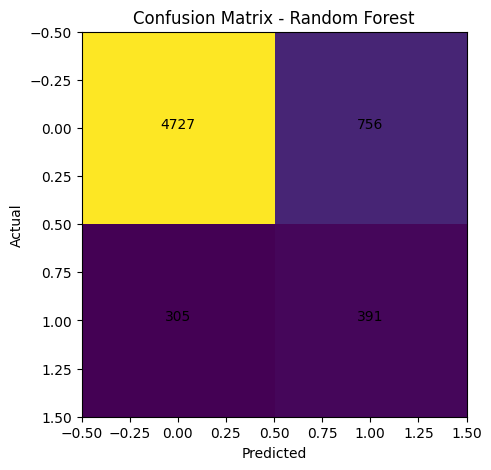

In [15]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,5))
plt.imshow(cm)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center')

plt.show()